# Solar's capture rate

A generator's "capture rate" is the volume-weighted price it actually
earns, relative to the plain average (baseload) day-ahead price over the
same period:

```
captured price = sum(price_h * generation_h) / sum(generation_h)
capture rate   = captured price / baseload price
```

A capture rate of 100% means the generator earns exactly the average
price. Solar's problem is structural: PV output is concentrated in a
fairly narrow set of daylight hours, and as more PV capacity gets built,
*all* of it produces into the same hours -- pushing the day-ahead price
down precisely when solar is on the margin (the standard merit-order
"cannibalization" effect). The more PV capacity there is, the more its own
output should depress the price it captures, relative to the average.

This page checks that directly for Germany: SMARD's DE-LU day-ahead
auction price against SMARD's observed solar generation, both already
used elsewhere in this book (`07_ttf_gas_vs_power_price`,
`04_pecd_potential_vs_smard_observed`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from insights.paths import hub_file

BASELOAD_COLOR = "#2a78d6"  # dataviz skill categorical slot 1 (blue)
CAPTURED_COLOR = "#eda100"  # dataviz skill categorical slot 4 (yellow) -- solar, matches 04's TECH_COLORS

## Loading and joining

**Same known SMARD data issue already documented in
`04_pecd_potential_vs_smard_observed`:** the DE-LU price series starts
right at the DE-LU market area's creation date (2018-10-01), but the
solar generation series has years of implausible near-zero placeholder
values before that date. Trimmed out here the same way, rather than
joining on it and treating it as genuine early history.

In [2]:
DE_LU_CREATION_DATE = "2018-10-01"

price = pd.read_parquet(hub_file("smard", "price_de_lu.parquet"))
generation = pd.read_parquet(hub_file("smard", "generation_solar.parquet")).rename(columns={"solar": "pv_mw"})

df = price.join(generation, how="inner").loc[DE_LU_CREATION_DATE:].dropna()
print(f"Joined panel: {df.shape}, {df.index.min()} .. {df.index.max()}")
df.tail()

Joined panel: (69948, 2), 2018-10-01 00:00:00 .. 2026-09-23 11:00:00


,price_de_lu,pv_mw
timestamp,,
2026-09-23 07:00:00,182.28,27135.06
2026-09-23 08:00:00,141.35,38559.58
2026-09-23 09:00:00,97.41,45863.69
2026-09-23 10:00:00,73.06,50236.44
2026-09-23 11:00:00,57.32,50449.30


## Monthly view: captured price vs. baseload price

The current, still-incomplete month is dropped, same reasoning as
`07_ttf_gas_vs_power_price`'s monthly aggregation.

In [3]:
current_month = pd.Timestamp.today().to_period("M")

monthly_baseload = df["price_de_lu"].resample("MS").mean()
monthly_captured = (df["price_de_lu"] * df["pv_mw"]).resample("MS").sum() / df["pv_mw"].resample("MS").sum()

monthly = pd.DataFrame({"baseload_eur_mwh": monthly_baseload, "captured_eur_mwh": monthly_captured})
monthly = monthly[monthly.index.to_period("M") < current_month]
monthly["capture_rate_pct"] = monthly["captured_eur_mwh"] / monthly["baseload_eur_mwh"] * 100
monthly.tail()

,baseload_eur_mwh,captured_eur_mwh,capture_rate_pct
timestamp,,,
2026-04-01,78.426333,20.265549,25.840236
2026-05-01,97.615793,38.883978,39.833696
2026-06-01,109.580403,64.656620,59.003817
2026-07-01,105.470067,54.954664,52.104512
2026-08-01,126.853414,66.609442,52.508986


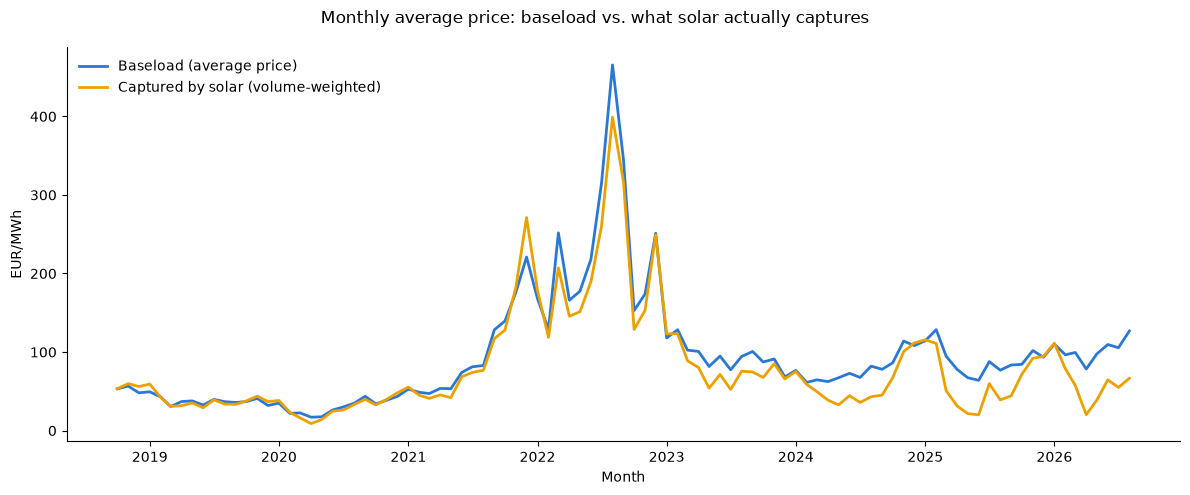

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly["baseload_eur_mwh"], color=BASELOAD_COLOR, linewidth=2, label="Baseload (average price)")
ax.plot(monthly.index, monthly["captured_eur_mwh"], color=CAPTURED_COLOR, linewidth=2, label="Captured by solar (volume-weighted)")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Month")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False)
fig.suptitle("Monthly average price: baseload vs. what solar actually captures")
fig.tight_layout()
plt.show()

## Monthly capture rate: seasonality dominates

Plotted as a ratio, one thing jumps out before any long-run trend does:
capture rate swings hard within a single year. Summer months push it down
(long, sunny days mean most PV output -- from the whole country's fleet at
once -- crowds into the same few midday hours) while winter months push it
back up (little PV output overall, and what little there is spreads more
evenly, so it's closer to an average-priced hour). That seasonal swing has
to be separated out before judging any year-over-year trend -- the next
section does that at annual resolution.

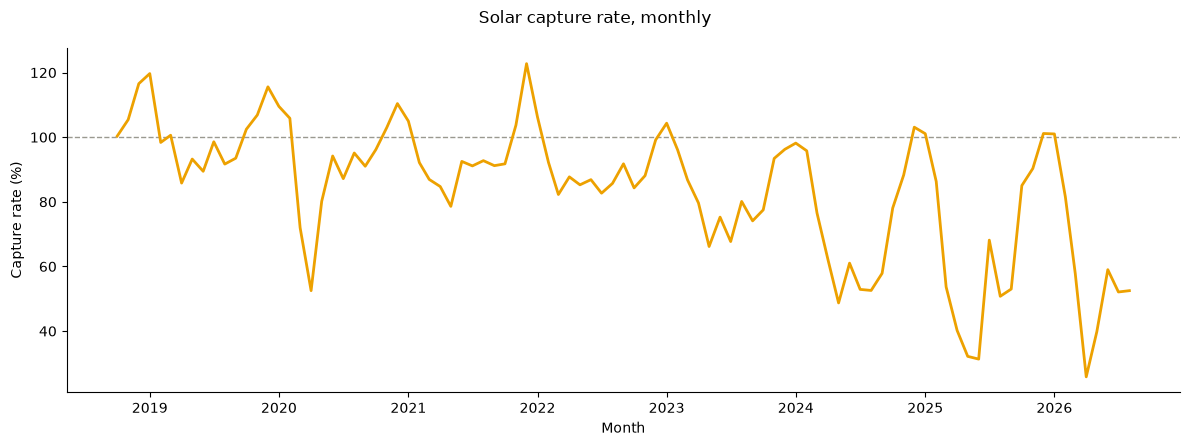

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axhline(100, color="#9a9990", linewidth=1, linestyle="--")
ax.plot(monthly.index, monthly["capture_rate_pct"], color=CAPTURED_COLOR, linewidth=2)
ax.set_ylabel("Capture rate (%)")
ax.set_xlabel("Month")
ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Solar capture rate, monthly")
fig.tight_layout()
plt.show()

## Annual capture rate: is the long-run trend really down?

Same calculation at annual resolution. 2018 is dropped here too -- the
join only starts 2018-10-01, so a calendar-year bucket for 2018 would
contain just Oct-Dec, a season that (per the chart above) structurally
runs a *high* capture rate, biasing that one data point up for a reason
that has nothing to do with the trend. The current, still-incomplete year
is dropped as well.

In [6]:
current_year = pd.Timestamp.today().to_period("Y")

annual_baseload = df["price_de_lu"].resample("YS").mean()
annual_captured = (df["price_de_lu"] * df["pv_mw"]).resample("YS").sum() / df["pv_mw"].resample("YS").sum()

annual = pd.DataFrame({"baseload_eur_mwh": annual_baseload, "captured_eur_mwh": annual_captured})
annual = annual[(annual.index.to_period("Y") < current_year) & (annual.index.year >= 2019)]
annual["capture_rate_pct"] = annual["captured_eur_mwh"] / annual["baseload_eur_mwh"] * 100
annual.index = annual.index.year
annual

,baseload_eur_mwh,captured_eur_mwh,capture_rate_pct
timestamp,,,
2019,37.668148,34.906193,92.667662
2020,30.471738,24.511219,80.439187
2021,96.849824,75.460116,77.914561
2022,235.439839,222.269611,94.406118
2023,95.176054,72.182107,75.840618
2024,78.512268,46.227981,58.879946
2025,89.328318,46.060532,51.563192


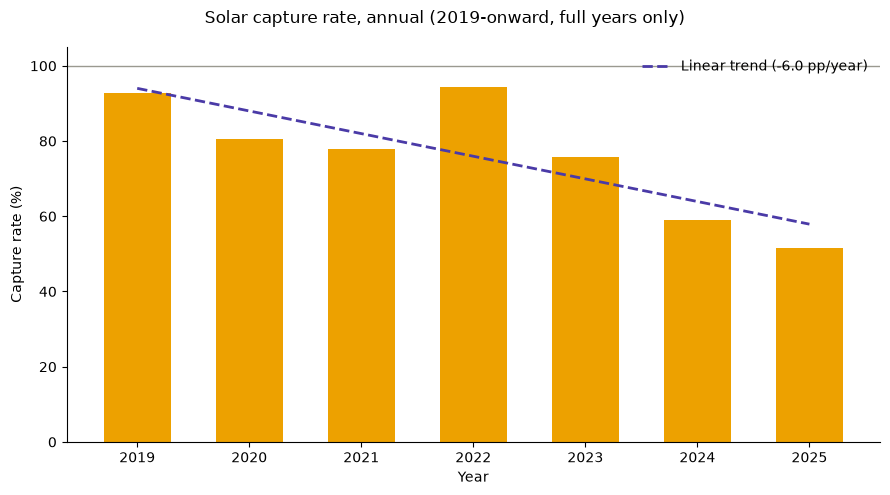

Linear trend: -6.02 percentage points per year
2019: 92.7% -> 2025: 51.6%


In [7]:
slope, intercept = np.polyfit(annual.index.values, annual["capture_rate_pct"].values, 1)
trend = slope * annual.index.values + intercept

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(annual.index, annual["capture_rate_pct"], color=CAPTURED_COLOR, width=0.6)
ax.plot(annual.index, trend, color="#4a3aa7", linewidth=2, linestyle="--", label=f"Linear trend ({slope:+.1f} pp/year)")
ax.axhline(100, color="#9a9990", linewidth=1)
ax.set_ylabel("Capture rate (%)")
ax.set_xlabel("Year")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right", frameon=False)
fig.suptitle("Solar capture rate, annual (2019-onward, full years only)")
fig.tight_layout()
plt.show()

print(f"Linear trend: {slope:+.2f} percentage points per year")
print(f"{annual.index.min()}: {annual['capture_rate_pct'].iloc[0]:.1f}% -> {annual.index.max()}: {annual['capture_rate_pct'].iloc[-1]:.1f}%")

The trend is unambiguous: solar's capture rate roughly halved over seven
full years, from the low-90s% in 2019 to just above 50% in 2025. 2022 is
the one clear outlier -- the continent-wide gas/power price spike lifted
*every* hour's price together, baseload and solar hours alike, so the
ratio between them jumps back up regardless of the underlying buildout
story. That one year aside, the decline is close to monotonic.

## Tying the decline to PV buildout directly

The year-over-year trend above is consistent with the cannibalization
hypothesis, but "capture rate fell as calendar years passed" isn't the
same claim as "capture rate fell *because* more PV got built." Plotting
capture rate against SMARD's own installed solar capacity for the same
years is the more direct test -- same correlation-scatter approach as
`07_ttf_gas_vs_power_price`'s gas-vs-power check.

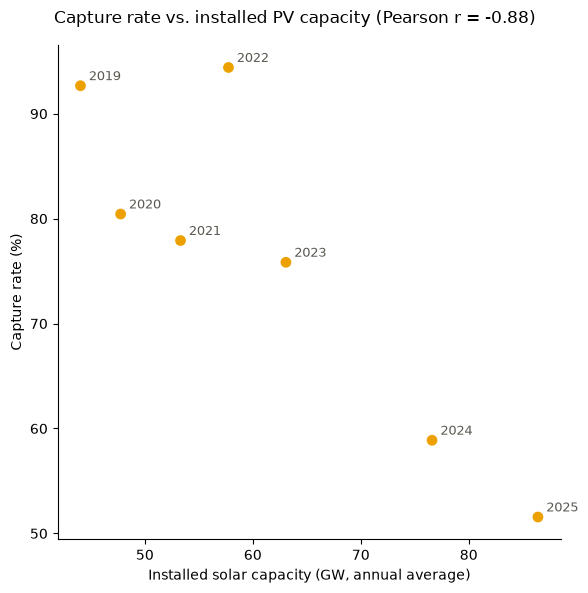

Pearson correlation, annual capture rate vs. installed PV capacity: -0.88


In [8]:
capacity = pd.read_parquet(hub_file("smard", "capacity_solar.parquet"))
annual_capacity_gw = capacity["capacity_solar"].resample("YS").mean() / 1000
annual_capacity_gw = annual_capacity_gw[(annual_capacity_gw.index.to_period("Y") < current_year) & (annual_capacity_gw.index.year >= 2019)]
annual_capacity_gw.index = annual_capacity_gw.index.year

annual["installed_capacity_gw"] = annual_capacity_gw
correlation = annual["installed_capacity_gw"].corr(annual["capture_rate_pct"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(annual["installed_capacity_gw"], annual["capture_rate_pct"], color=CAPTURED_COLOR, s=60, edgecolors="none")
for year, row in annual.iterrows():
    ax.annotate(str(year), (row["installed_capacity_gw"], row["capture_rate_pct"]), textcoords="offset points", xytext=(6, 4), fontsize=9, color="#5a5850")
ax.set_xlabel("Installed solar capacity (GW, annual average)")
ax.set_ylabel("Capture rate (%)")
ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Capture rate vs. installed PV capacity (Pearson r = {correlation:.2f})")
fig.tight_layout()
plt.show()

print(f"Pearson correlation, annual capture rate vs. installed PV capacity: {correlation:.2f}")

Capacity roughly doubled (44 GW to 86 GW) over the same seven years
capture rate roughly halved, and the two track each other closely (r =
-0.88) -- including 2022 sitting off to the side as the one year where
price level, not PV buildout, was doing the driving. That's the
cannibalization story in the data: not just "capture rate fell over time"
but "capture rate fell in step with how much PV capacity actually got
added."